In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sph import integrate, animate_particles

In [2]:
np.random.seed(0)

In [3]:
no_particles = 100
no_steps = 100
L = 3
h = 0.5
v0 = 0.1
dt = 0.01
c_s = 10
rho0 = 10
masses = np.array([1]*no_particles)

initial_positions = np.random.random(size=(no_particles,2))*L
initial_velocities = np.random.normal(size=(no_particles,2))*v0

In [4]:
positions, velocities = integrate(initial_positions, initial_velocities, masses, L, h, c_s, rho0, dt, no_steps)

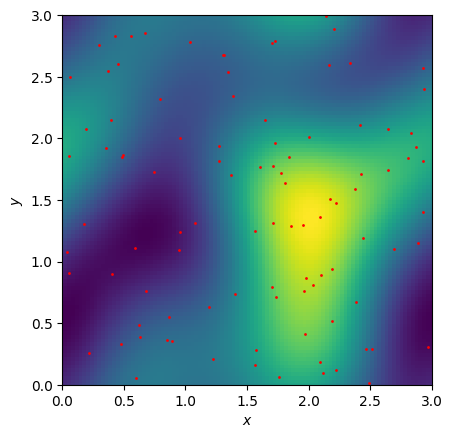

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1920x1440', '-pix_fmt', 'rgba', '-framerate', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-vcodec', 'libx264', '-y', 'animation.mp4']' returned non-zero exit status 255.

In [5]:
animate_particles(positions, masses, L, h, no_steps)

### Check mass conservation
The mass from integrating the density is slighly smaller than the summed particle masses, since the density grid only takes into account the density from the nearest image of a particle. Since our kernel is gaussian, and thus extends infinitely, there are other images of the particle that still give non-zero  integrated density 

In [ ]:
from sph import get_density_grid

grid_size = 100
dV = (L/grid_size)**2 # volume element
x,y,rho = get_density_grid(positions[0], masses, L, h, grid_size=grid_size)

print(f"Integrated density =  {np.sum(rho*dV):.2f}")
print(f"Summed particle masses = {np.sum(masses):.2f}")

Integrated density =  99.39
Summed particle masses = 100.00


In [ ]:
print(np.exp(-1/2*(L**2/h**2)))

1.522997974471263e-08
